In [50]:
import time
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import RXXGate, SwapGate, iSwapGate
from qiskit.quantum_info import Operator
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from tqdm import tqdm
from scipy.optimize import least_squares

# The following are imported from the weylchamber package.
from weylchamber import c1c2c3, g1g2g3

import jax.numpy as jnp
import numpy as np
from jax import config, jacfwd, jit
from jax.random import PRNGKey, uniform
from jaxopt import GaussNewton, LevenbergMarquardt, ScipyLeastSquares
from jaxopt.linear_solve import solve_cg

from monodromy.coverage import gates_to_coverage
from monodromy.coordinates import monodromy_to_positive_canonical_coordinate
from monodromy.render import _plot_coverage_set

import numpy as np
from scipy.spatial import ConvexHull
from weylchamber import WeylChamber
from weylchamber import canonical_gate

In [51]:
config.update("jax_enable_x64", True)

MAGIC = jnp.array(
    [[1, 0, 0, 1j], [0, 1j, 1, 0], [0, 1j, -1, 0], [1, 0, 0, -1j]],
    dtype=jnp.cdouble,
) / jnp.sqrt(2)

ATOL = 0  # arbitrary, a little bit less than float
CONV_TOL = 0  # forces to use all alloted iterations

xx_gate = iSwapGate().power(1 / 4)
basis_gate = jnp.array(xx_gate.to_matrix(), dtype=jnp.complex128)


@jit
def two_qubit_local_invariants(U):
    # same as qiskit.synthesis.local_invariance.two_qubit_local_invariants
    # but with jax :)
    Um = MAGIC.conj().T.dot(U.dot(MAGIC))
    det_um = jnp.complex128(jnp.linalg.det(Um))
    M = jnp.dot(Um.T, Um)
    m_tr2 = jnp.trace(M)
    m_tr2 *= m_tr2
    G1 = m_tr2 / (16 * det_um)
    G2 = (m_tr2 - jnp.trace(M.dot(M))) / (4 * det_um)
    return jnp.array([G1.real, G1.imag, G2.real], dtype=jnp.double)


@jit
def _rv(v):
    # taken from qiskit.library.RV
    # half_angle = jnp.sqrt(jnp.dot(v, v)) / 2
    half_angle = jnp.double(jnp.linalg.norm(v) / 2)
    nx, ny, nz = v / (2 * half_angle)
    sin = jnp.sin(half_angle)
    cos = jnp.cos(half_angle)
    return jnp.array(
        [
            [cos - 1j * nz * sin, (-ny - 1j * nx) * sin],
            [(ny - 1j * nx) * sin, cos + 1j * nz * sin],
        ],
        dtype=jnp.cdouble,
    )


@jit
def _construct_op_generic(x: jnp.ndarray):
    # Infer the circuit depth d from the length of x.
    d = x.shape[0] // 6 + 1  # d >= 1
    U = basis_gate  # start with the initial XX gate
    # For each interior layer, multiply by a local pair of RV gates and an XX gate.
    for i in range(d - 1):
        local = jnp.kron(_rv(x[6 * i : 6 * i + 3]), _rv(x[6 * i + 3 : 6 * i + 6]))
        U = basis_gate @ local @ U
    return U


@jit
def _objective_function_generic(x: jnp.ndarray, target_inv: jnp.ndarray):
    U = _construct_op_generic(x)
    construct_inv = two_qubit_local_invariants(U)
    return target_inv - construct_inv


# Build a Levenberg–Marquardt optimizer using the generic objective function.
j_lm_generic = LevenbergMarquardt(
    residual_fun=_objective_function_generic,
    maxiter=2048,
    solver=solve_cg,
    implicit_diff=False,
    materialize_jac=True,
    jit=True,
    tol=CONV_TOL,
    # xtol=CONV_TOL,
    # gtol=CONV_TOL,
)

In [52]:
def create_parametrized_xx_circuit(depth: int) -> QuantumCircuit:
    qc = QuantumCircuit(2)
    segments = (
        []
    )  # list to hold parameters (p0, p1) for RV gate blocks on qubit 0 and 1
    param_counter = 0
    total_rv_segments = depth + 1

    # Generate RV segments for each layer except the final one.
    for seg in range(total_rv_segments - 1):
        p0 = [Parameter(f"x{param_counter + i}") for i in range(3)]
        param_counter += 3
        p1 = [Parameter(f"x{param_counter + i}") for i in range(3)]
        param_counter += 3
        segments.append((p0, p1))

    # Begin the circuit by appending the first XX gate.
    qc.append(xx_gate, [0, 1])

    # For each additional layer, insert the RV gates followed by another XX gate.
    for layer in range(depth - 1):
        qc.rv(*segments[layer][0], 0)
        qc.rv(*segments[layer][1], 1)
        qc.append(xx_gate, [0, 1])
    return qc

In [53]:
# Create a circuit with a specified depth (for example, depth = 3)
depth_demo = 3
qc_demo = create_parametrized_xx_circuit(depth_demo)

# Visualize the circuit
qc_demo.draw(output="mpl")
plt.show()

# Print the total number of parameters in the circuit.
print("Number of parameters:", len(qc_demo.parameters))

# Generate random parameter values and bind them to create a fixed circuit.
parameter_values = {
    param: np.random.uniform(-2 * np.pi, 2 * np.pi) for param in qc_demo.parameters
}
bound_qc_demo = qc_demo.assign_parameters(parameter_values)

# Extract and print the unitary matrix of the bound circuit.
unitary_demo = Operator(bound_qc_demo).data
print("Unitary matrix:")
print(unitary_demo)

Number of parameters: 12
Unitary matrix:
[[-1.78880211e-05+0.0488013j   2.57773499e-01-0.45672693j
  -5.27165179e-01-0.58464725j -1.59489997e-01+0.27824301j]
 [ 3.34441724e-01+0.41724851j -8.32708247e-02-0.06708209j
  -2.23003908e-01+0.05712988j -4.51712270e-01-0.66751767j]
 [ 5.36588675e-01-0.6249072j   3.93660761e-03+0.10442757j
  -1.53748980e-01-0.24484541j  3.40837767e-01-0.33299335j]
 [ 1.55019734e-01-0.09593394j  4.90887016e-01-0.67943257j
   2.99411767e-01+0.39249774j  9.56248944e-02-0.10639961j]]


In [54]:
def cost_function(x, qc_template, target):
    # Bind the parameters.
    param_dict = dict(zip(qc_template.parameters, x))
    bound_qc = qc_template.assign_parameters(param_dict)
    U = Operator(bound_qc).data

    # scalar cost function
    # return np.sum(np.abs(np.array(g1g2g3(U)) - target) ** 2)

    # residual vector cost function
    # Compute the residual vector between the Makhlin invariants.
    residuals = target - two_qubit_local_invariants(U)
    return residuals

In [55]:
import time
import numpy as np


def optimize_circuit(qc_template, target, threshold=1e-8, max_restarts=1):
    num_params = len(qc_template.parameters)
    # Start timer using a monotonic clock.
    start_time = time.perf_counter()

    x0 = np.random.uniform(-2 * np.pi, 2 * np.pi, num_params)
    res = j_lm_generic.run(x0, target)

    # Ensure computation is finished by blocking until the residual is computed.
    res_state = res.state.residual.block_until_ready()
    # Check convergence: all components of the residual below threshold.
    if np.all(np.abs(np.array(res_state)) < threshold):
        # print("converged")
        duration = time.perf_counter() - start_time
        return True
    duration = time.perf_counter() - start_time
    return False

In [56]:
def sample_on_triangle_edges(vertices, n_samples=1):
    v0, v1, v2 = vertices
    # Compute lengths of the three edges.
    edge_lengths = [
        np.linalg.norm(v1 - v0),
        np.linalg.norm(v2 - v1),
        np.linalg.norm(v0 - v2),
    ]
    total_length = sum(edge_lengths)
    samples = []
    for _ in range(n_samples):
        r = np.random.uniform(0, total_length)
        # Determine on which edge the point falls.
        if r < edge_lengths[0]:
            # On edge from v0 to v1
            t = r / edge_lengths[0]
            point = (1 - t) * v0 + t * v1
        elif r < edge_lengths[0] + edge_lengths[1]:
            # On edge from v1 to v2
            r_adj = r - edge_lengths[0]
            t = r_adj / edge_lengths[1]
            point = (1 - t) * v1 + t * v2
        else:
            # On edge from v2 to v0
            r_adj = r - (edge_lengths[0] + edge_lengths[1])
            t = r_adj / edge_lengths[2]
            point = (1 - t) * v2 + t * v0
        samples.append(point)
    return np.array(samples)


def sample_polytope_surface(vertices, n_samples=1):
    vertices = np.asarray(vertices)

    # return vertex with largest z coordinate
    samples = []
    for _ in range(n_samples):
        max_z_index = np.argmax(vertices[:, 2])
        max_z_vertex = vertices[max_z_index]
        samples.append(max_z_vertex)
    return np.array(samples)

    if vertices.shape[0] == 2:
        # Edge case: a line segment.
        v0, v1 = vertices
        t = np.random.uniform(0, 1, n_samples)
        return (1 - t)[:, np.newaxis] * v0 + t[:, np.newaxis] * v1

    if vertices.shape[0] == 3:
        # Edge case: a triangle.
        return sample_on_triangle_edges(vertices, n_samples)
    else:
        hull = ConvexHull(vertices)
        samples = []
        for _ in range(n_samples):
            facet_indices = hull.simplices[np.random.choice(len(hull.simplices))]
            facet_vertices = vertices[facet_indices]
            # Generate random barycentric coordinates that sum to 1.
            weights = np.random.dirichlet(np.ones(len(facet_vertices)))
            sample_point = np.dot(weights, facet_vertices)
            samples.append(sample_point)
        return np.array(samples)

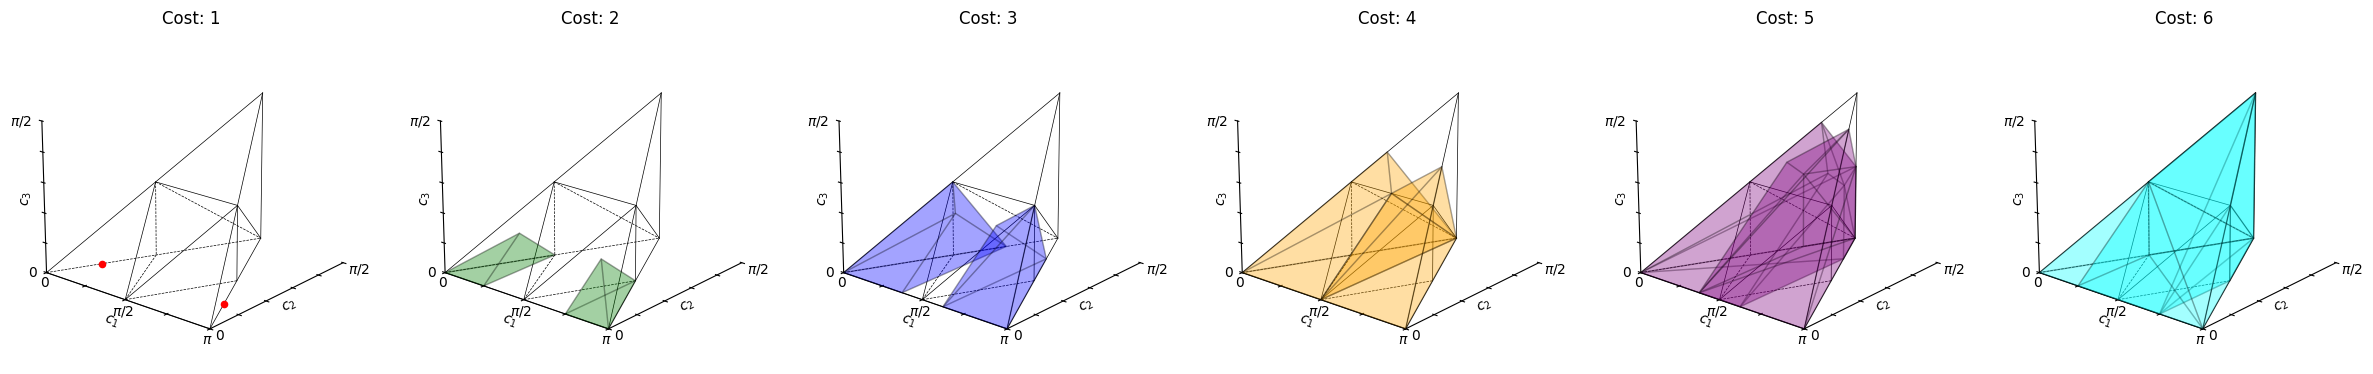

In [57]:
# Example usage:
# Sample 100 random points on the surface:
coverage_set = gates_to_coverage(
    xx_gate, costs=[1], names=["cx"], instructions=[xx_gate]
)

_plot_coverage_set(coverage_set)

In [58]:
def surface_sample(depth, n_samples):
    circuit_polytope = coverage_set[depth]
    polytope_vertices = np.array(
        [
            monodromy_to_positive_canonical_coordinate(*a)
            for a in circuit_polytope.reduce().vertices[0]
        ]  # [0] to pick either left or right
    ) / (np.pi / 2)

    # if depth >= 3:
    #     prev_depth_vertices = np.array(
    #         [
    #             monodromy_to_positive_canonical_coordinate(*a)
    #             for a in coverage_set[depth - 1].reduce().vertices[0]
    #         ]
    #     ) / (np.pi / 2)
    #     max_z = np.max(prev_depth_vertices[:, 2])

    #     # add additional vertices so we avoid polytopes from the previous layer
    #     # add points at (z,z,z), (1-z, z,z), and (0.5,0.5, z)
    #     # where z is highest coordinate of the previous layer
    #     # this defines a horizontal triangle that should be entirely above the previous layer
    #     polytope_vertices = np.concatenate(
    #         [
    #             polytope_vertices,
    #             np.array(
    #                 [
    #                     [max_z, max_z, max_z],
    #                     [1 - max_z, max_z, max_z],
    #                     [0.5, 0.5, max_z],
    #                 ]
    #             ),
    #         ]
    #     )

    # I want to sample from the unique faces of the circuit polytope
    # however for XY gates they overlap
    points_on_surface = sample_polytope_surface(polytope_vertices, n_samples)

    w = WeylChamber()
    w.labels = {}
    ax = plt.subplot(111, projection="3d", computed_zorder=False)
    w.render(ax)
    w.ax.scatter3D(*zip(*points_on_surface), zorder=-1)

    gates_on_surface = []
    for point in points_on_surface:
        u = canonical_gate(*point)
        gates_on_surface.append(u)
    return gates_on_surface


Running experiments for circuit depth = 2
  Circuit has 6 parameters.


Depth 2: 100%|██████████| 128/128 [00:09<00:00, 13.87it/s]


Depth 2: Completed 128 trials.

Running experiments for circuit depth = 3
  Circuit has 12 parameters.


Depth 3: 100%|██████████| 128/128 [00:10<00:00, 11.67it/s]


Depth 3: Completed 128 trials.

Running experiments for circuit depth = 4
  Circuit has 18 parameters.


...

Depth 4: Completed 128 trials.

Running experiments for circuit depth = 5
  Circuit has 24 parameters.


Depth 5: 100%|██████████| 128/128 [00:17<00:00,  7.23it/s]


Depth 5: Completed 128 trials.

Running experiments for circuit depth = 6
  Circuit has 30 parameters.


Depth 6: 100%|██████████| 128/128 [00:23<00:00,  5.54it/s]


Depth 6: Completed 128 trials.


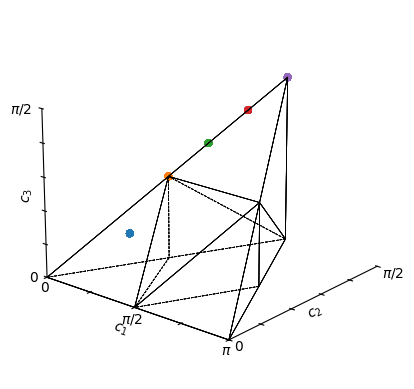

In [59]:
# Define the circuit depths and number of optimization trials per depth.
depths = [2, 3, 4, 5, 6]
num_trials = 128

# Dictionary to store results for each depth.
# Each entry will now be a tuple: (restarts_used, duration, final_residual)
results = {d: [] for d in depths}

for d in depths:
    print(f"\nRunning experiments for circuit depth = {d}")
    qc_template = create_parametrized_xx_circuit(d)
    num_params = len(qc_template.parameters)
    print(f"  Circuit has {num_params} parameters.")

    surface_sampled_gates = surface_sample(d, num_trials)

    for trial in tqdm(range(num_trials), desc=f"Depth {d}"):
        # # Generate a random target by binding random parameters.
        # random_params = {
        #     param: np.random.uniform(-2 * np.pi, 2 * np.pi)
        #     for param in qc_template.parameters
        # }
        # qc_target = qc_template.assign_parameters(random_params)
        # target = two_qubit_local_invariants(Operator(qc_target).data)

        qc_target = surface_sampled_gates[trial]

        # Use g1g2g3 to get the target invariants.
        target = two_qubit_local_invariants(qc_target.full())

        # Optimize the circuit parameters using the chosen approach.
        converged_bool = optimize_circuit(qc_template, target)
        results[d].append(converged_bool)

    print(f"Depth {d}: Completed {num_trials} trials.")

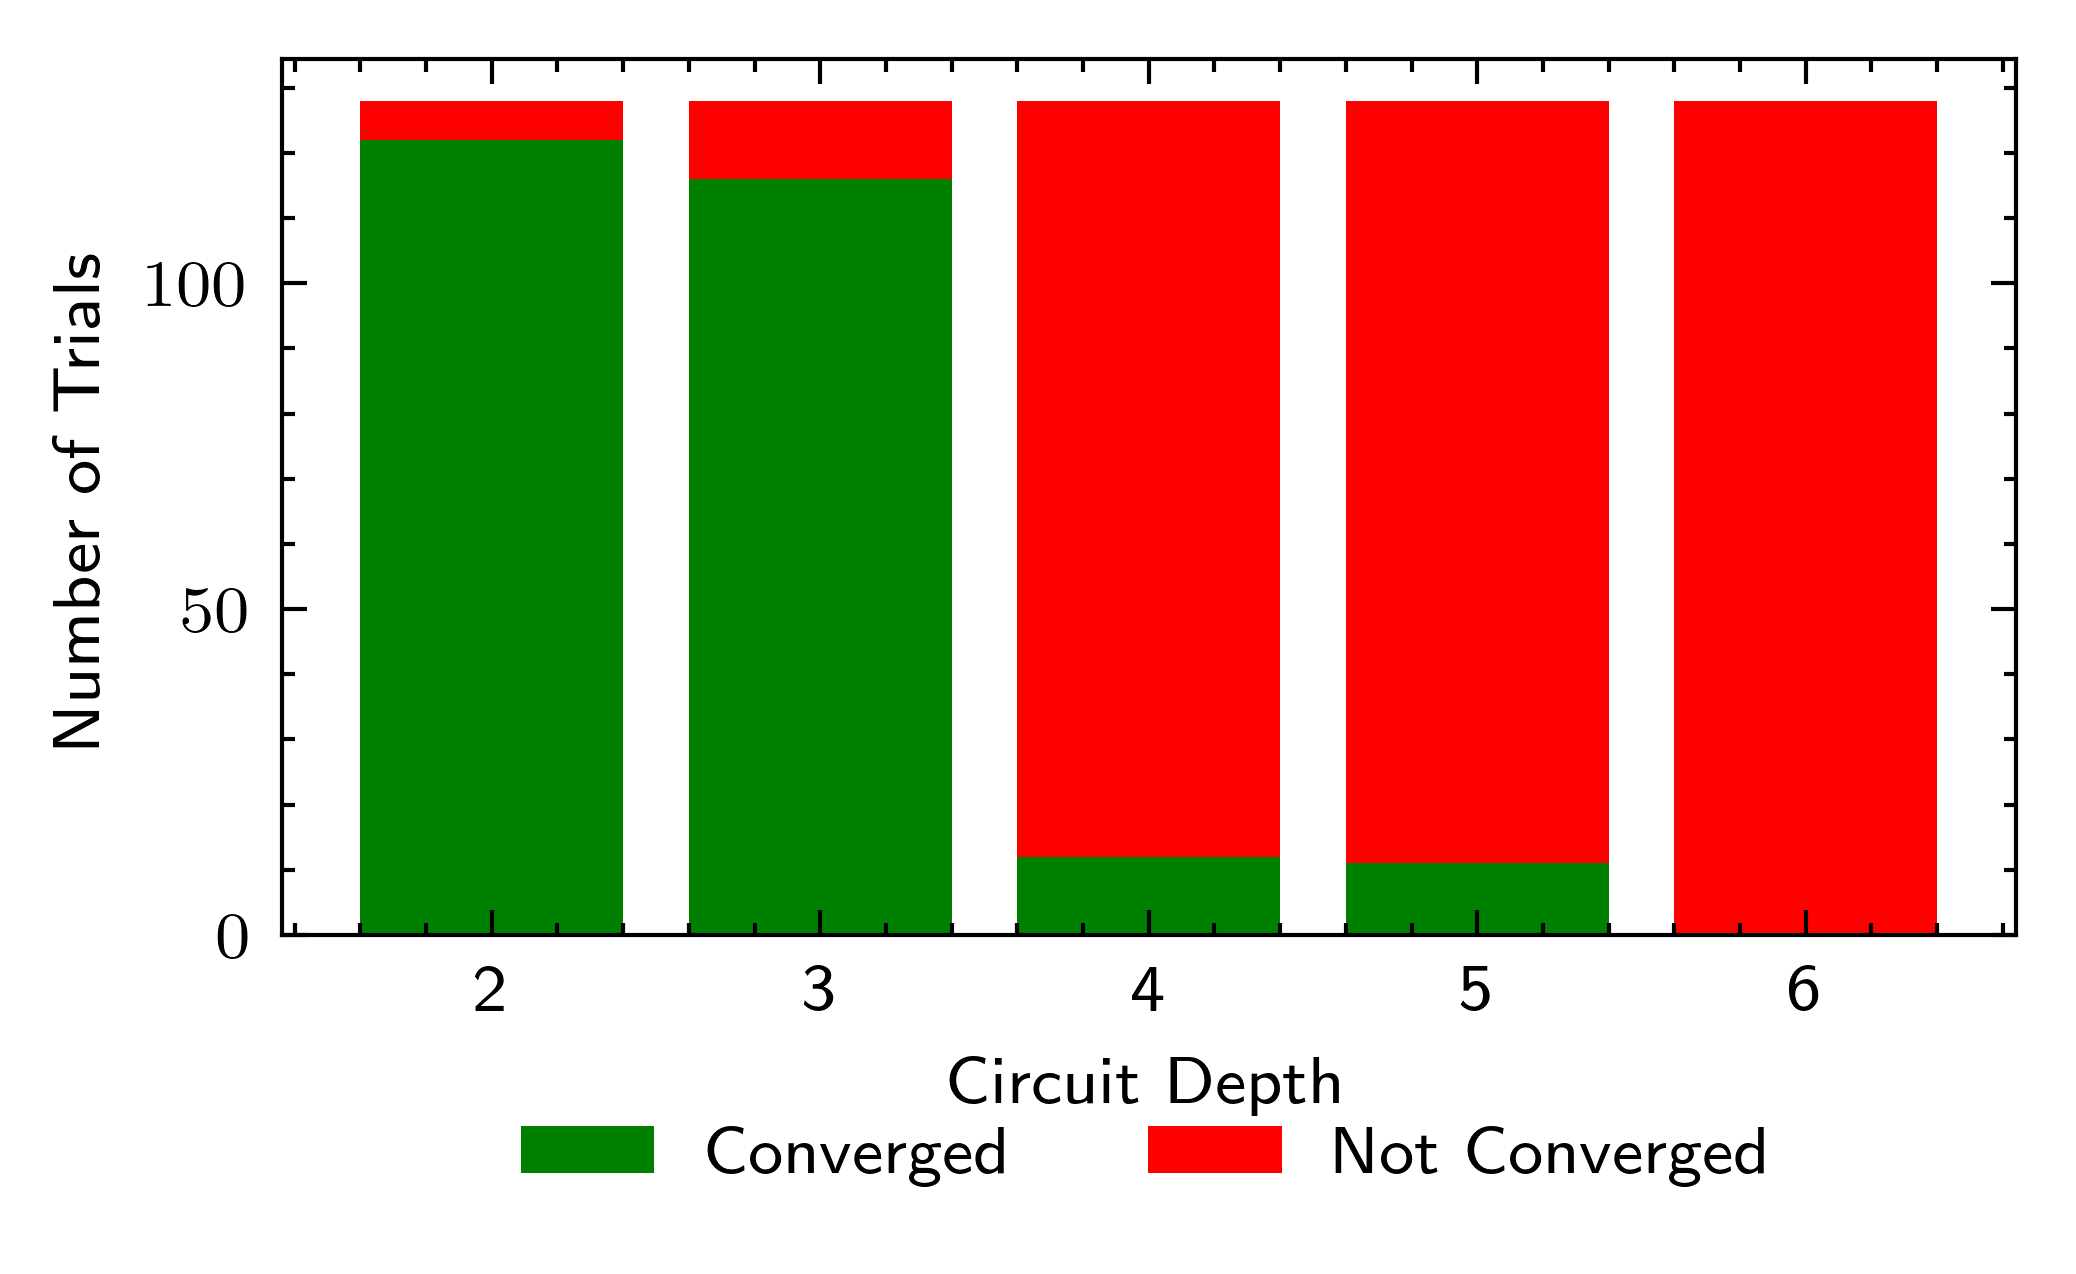

In [63]:
import matplotlib.pyplot as plt
import numpy as np
import lovelyplots
import scienceplots

# Process the results: count converged (True) vs non-converged (False) for each depth.
depths_sorted = sorted(results.keys())
converged_counts = []
non_converged_counts = []

for d in depths_sorted:
    trials = results[d]  # List of booleans.
    count_conv = sum(trials)  # True counts as 1.
    count_non_conv = len(trials) - count_conv
    converged_counts.append(count_conv)
    non_converged_counts.append(count_non_conv)

# Create a stacked bar chart using your style.
with plt.style.context(["ieee", "use_mathtext", "science"]):
    fig, ax = plt.subplots(1, 1, figsize=(3.5, 2.2))
    x = np.arange(len(depths_sorted))

    # Plot the "Converged" counts (green bars).
    bar1 = ax.bar(x, converged_counts, color="green", label="Converged")
    # Plot the "Not Converged" counts (red bars) stacked on top of the converged counts.
    bar2 = ax.bar(
        x,
        non_converged_counts,
        bottom=converged_counts,
        color="red",
        label="Not Converged",
    )

    # Set x-axis tick labels to the circuit depths.
    ax.set_xticks(x)
    ax.set_xticklabels(depths_sorted)
    ax.set_xlabel("Circuit Depth")
    ax.set_ylabel("Number of Trials")

    # Place the legend below the figure.
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)

    fig.tight_layout()
plt.savefig("convergence_plot.pdf", bbox_inches="tight")
plt.show()